# SKAX 이탈 예측 모델

## 전체 파이프라인
1. 데이터 전처리
2. 피처 엔지니어링
3. 모델용 테이블 병합
4. 모델링
5. 평가 & 인사이트

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rc

rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', None)

membership   = pd.read_csv('Membership.csv')
movie_master = pd.read_csv('Movie_Master.csv')
view_history = pd.read_csv('View_History.csv')
user_mapping = pd.read_csv('User_Mapping.csv')

print('Membership   :', membership.shape)
print('Movie_Master :', movie_master.shape)
print('View_History :', view_history.shape)
print('User_Mapping :', user_mapping.shape)

Membership   : (18183, 15)
Movie_Master : (14018, 3)
View_History : (106205, 5)
User_Mapping : (19877, 2)


---
## Step 1. 데이터 전처리

### 1-1. 중복 데이터 확인 & 제거

In [76]:
# 각 테이블 중복 확인
for name, df, key_cols in [
    ('Membership',   membership,   ['user_no']),
    ('Movie_Master', movie_master, ['MOVIE_ID']),
    ('View_History', view_history, ['USER_ID','MOVIE_ID','WATCH_DAY','WATCH_SEQ']),
    ('User_Mapping', user_mapping, ['uid'])
]:
    total   = len(df)
    dup_all = df.duplicated().sum()
    dup_key = df.duplicated(subset=key_cols).sum()
    print(f'[{name}]')
    print(f'  전체 행 수          : {total:,}')
    print(f'  완전 중복 행        : {dup_all:,}')
    print(f'  키 기준 중복({key_cols}): {dup_key:,}')
    print()

[Membership]
  전체 행 수          : 18,183
  완전 중복 행        : 0
  키 기준 중복(['user_no']): 338

[Movie_Master]
  전체 행 수          : 14,018
  완전 중복 행        : 0
  키 기준 중복(['MOVIE_ID']): 0

[View_History]
  전체 행 수          : 106,205
  완전 중복 행        : 0
  키 기준 중복(['USER_ID', 'MOVIE_ID', 'WATCH_DAY', 'WATCH_SEQ']): 0

[User_Mapping]
  전체 행 수          : 19,877
  완전 중복 행        : 0
  키 기준 중복(['uid']): 49



In [77]:
# 중복 케이스 상세 확인

# ── Membership 중복 user_no ──────────────────────────
print('=' * 60)
print('[Membership] 동일 user_no 샘플 (상위 10명)')
print('=' * 60)
dup_mem = membership[membership.duplicated(subset=['user_no'], keep=False)]
print(dup_mem.sort_values('user_no')
      [['user_no','product_cd','amount','reg_date','end_date','repurchase']]
      .head(10).to_string())

# 당일 취소(reg_date == end_date) 건수
membership['reg_date'] = pd.to_datetime(membership['reg_date'])
membership['end_date'] = pd.to_datetime(membership['end_date'])
same_day = membership[membership['reg_date'] == membership['end_date']]
print(f'당일 취소(reg_date == end_date): {len(same_day):,}건')
print(same_day[['product_cd','amount','reg_date','end_date','repurchase']].head(5).to_string())

# ── User_Mapping 중복 uid ────────────────────────────
print('' + '=' * 60)
print('[User_Mapping] 동일 uid → USER_ID 2개 샘플')
print('=' * 60)
dup_uid = user_mapping[user_mapping.duplicated(subset=['uid'], keep=False)]
print(dup_uid.sort_values('uid').head(10).to_string())
print(f'중복 uid 총 건수: {len(dup_uid):,} (유니크 uid: {dup_uid["uid"].nunique():,}명)')

[Membership] 동일 user_no 샘플 (상위 10명)
                                                                                                                                user_no product_cd    amount    reg_date    end_date repurchase
12503  01b73db46b0b3f6c24ca22dc4629ed41ed0d6ac4beccf86c2832489b59f95d13769eb6b22590f386e43b25ab771db9bc2d77d6db82a3e53c783a9a55b4f2f523    pk_1487    100.00  2021-03-14  2021-03-14        NaN
13091  01b73db46b0b3f6c24ca22dc4629ed41ed0d6ac4beccf86c2832489b59f95d13769eb6b22590f386e43b25ab771db9bc2d77d6db82a3e53c783a9a55b4f2f523    pk_1488  10900.00  2021-03-14  2021-04-14        NaN
13036  0258fd467c5765400d487d203f7c77afb597120daa9b1ede96e6a06122e89ea3120f1c5b6932ce435b954aab5da1999305ab7de84225bd741ee334c26ff1ce33    pk_1506     13.49  2021-03-12  2021-03-12        NaN
6647   0258fd467c5765400d487d203f7c77afb597120daa9b1ede96e6a06122e89ea3120f1c5b6932ce435b954aab5da1999305ab7de84225bd741ee334c26ff1ce33    pk_1508      9.99  2021-03-11  2021-04-12        NaN
8796

In [78]:
# ── 중복 제거 ────────────────────────────────────────

# Membership: 동일 user_no 중 reg_date 최신 1건만 유지
membership['reg_date'] = pd.to_datetime(membership['reg_date'])
membership['end_date'] = pd.to_datetime(membership['end_date'])
membership_clean = (membership
                    .sort_values('reg_date', ascending=False)
                    .drop_duplicates(subset=['user_no'], keep='first')
                    .reset_index(drop=True))

# User_Mapping: 동일 uid → 기기별 USER_ID (다기기 등록) → 삭제하지 않음
# uid 1개가 USER_ID 여러 개를 가질 수 있음 (최대 3개 확인됨)
user_mapping_clean = user_mapping.copy().reset_index(drop=True)

print('[중복 제거 결과]')
print(f'Membership   : {len(membership):,} → {len(membership_clean):,} ({len(membership)-len(membership_clean):,}건 제거)')
print(f'User_Mapping : {len(user_mapping):,} → {len(user_mapping_clean):,} (다기기 등록 유지, 제거 없음)')

# CSV 저장
membership_clean.to_csv('Membership_전처리.csv', index=False, encoding='utf-8-sig')
user_mapping_clean.to_csv('User_Mapping_전처리.csv', index=False, encoding='utf-8-sig')

print('Membership_전처리.csv 저장 완료')
print('User_Mapping_전처리.csv 저장 완료')


[중복 제거 결과]
Membership   : 18,183 → 17,845 (338건 제거)
User_Mapping : 19,877 → 19,877 (다기기 등록 유지, 제거 없음)
Membership_전처리.csv 저장 완료
User_Mapping_전처리.csv 저장 완료


### 1-2. 결측치 확인

In [79]:
# 전처리된 파일 로드
membership_c   = pd.read_csv('Membership_전처리.csv')
user_mapping_c = pd.read_csv('User_Mapping_전처리.csv')

# 각 테이블 결측치 현황
for name, df in [('Membership_전처리', membership_c),
                  ('Movie_Master',     movie_master),
                  ('View_History',     view_history),
                  ('User_Mapping_전처리', user_mapping_c)]:
    null_cnt = df.isnull().sum()
    null_pct = df.isnull().mean() * 100
    null_df  = pd.DataFrame({'결측수': null_cnt, '결측률(%)': null_pct.round(1)})
    null_df  = null_df[null_df['결측수'] > 0].sort_values('결측률(%)', ascending=False)
    print(f'[{name}] 전체 행: {len(df):,}')
    if null_df.empty:
        print('  결측치 없음')
    else:
        print(null_df.to_string())
    print()

[Membership_전처리] 전체 행: 17,845
                      결측수  결측률(%)
is_churn_prevented  14645    82.1
promotion_yn         8688    48.7
repurchase           6000    33.6
is_user_verified      585     3.3
gender                152     0.9
age                   152     0.9
concurrent_streams     61     0.3

[Movie_Master] 전체 행: 14,018
  결측치 없음

[View_History] 전체 행: 106,205
  결측치 없음

[User_Mapping_전처리] 전체 행: 19,877
  결측치 없음



In [80]:
# gender NaN = age NaN 동일 행 확인
gender_nan = set(membership_c[membership_c['gender'].isna()].index)
age_nan    = set(membership_c[membership_c['age'].isna()].index)

print(f'gender NaN 행 수: {len(gender_nan):,}')
print(f'age NaN 행 수:    {len(age_nan):,}')
print(f'완전히 동일한 행: {len(gender_nan & age_nan):,}')
print(f'gender NaN이지만 age 있음: {len(gender_nan - age_nan):,}')
print(f'age NaN이지만 gender 있음: {len(age_nan - gender_nan):,}')
print()

# 해당 행들 상세 확인
both_nan = membership_c[membership_c['gender'].isna() & membership_c['age'].isna()]
print('[gender & age 동시 결측 행 상세]')
print(both_nan[['product_cd','amount','gender','age','payment_device',
                'is_user_verified','reg_date']].to_string())
print()

# 미인증 여부 확인
print('[gender & age 결측 행의 is_user_verified 분포]')
print(both_nan['is_user_verified'].value_counts(dropna=False))
print()
not_nan = membership_c[membership_c['gender'].notna()]
print('[gender & age 정상 행의 is_user_verified 분포 (비교용)]')
print(not_nan['is_user_verified'].value_counts(dropna=False))

gender NaN 행 수: 152
age NaN 행 수:    152
완전히 동일한 행: 152
gender NaN이지만 age 있음: 0
age NaN이지만 gender 있음: 0

[gender & age 동시 결측 행 상세]
      product_cd    amount gender  age payment_device is_user_verified    reg_date
128      pk_1487    100.00    NaN  NaN             pc              NaN  2021-03-15
221      pk_1508      9.99    NaN  NaN            ios              NaN  2021-03-15
379      pk_1487    100.00    NaN  NaN         mobile              NaN  2021-03-15
394      pk_1489    100.00    NaN  NaN             pc              NaN  2021-03-15
585      pk_1487    100.00    NaN  NaN         mobile              NaN  2021-03-15
719      pk_1487    100.00    NaN  NaN         mobile              NaN  2021-03-15
759      pk_1487   7900.00    NaN  NaN             pc              NaN  2021-03-15
965      pk_1488    100.00    NaN  NaN        android              NaN  2021-03-14
1078     pk_1488    100.00    NaN  NaN             pc              NaN  2021-03-14
1214     pk_2005   3350.00    NaN  NaN  

In [81]:
# 결측치 처리

# gender NaN -> 'N'
membership_c['gender'] = membership_c['gender'].fillna('N')

# is_user_verified NaN -> 'N'
membership_c['is_user_verified'] = membership_c['is_user_verified'].fillna('N')

# promotion_yn NaN -> 'N'
membership_c['promotion_yn'] = membership_c['promotion_yn'].fillna('N')

# is_churn_prevented NaN -> 'N'
membership_c['is_churn_prevented'] = membership_c['is_churn_prevented'].fillna('N')

print('[결측치 처리 결과]')
for col in ['gender','is_user_verified','promotion_yn','is_churn_prevented']:
    print(f'{col}: {membership_c[col].isna().sum()}건 남음')
    print(f'  분포: {membership_c[col].value_counts().to_dict()}')
    print()

print('[age 결측치 (미결)]')
print(f'age NaN: {membership_c["age"].isna().sum():,}건')
print(membership_c[membership_c['age'].isna()][['product_cd','gender','age','is_user_verified','payment_device']].to_string())

[결측치 처리 결과]
gender: 0건 남음
  분포: {'F': 9349, 'M': 5595, 'N': 2901}

is_user_verified: 0건 남음
  분포: {'Y': 13306, 'N': 4539}

promotion_yn: 0건 남음
  분포: {'O': 9157, 'N': 8688}

is_churn_prevented: 0건 남음
  분포: {'N': 14645, 'O': 3200}

[age 결측치 (미결)]
age NaN: 152건
      product_cd gender  age is_user_verified payment_device
128      pk_1487      N  NaN                N             pc
221      pk_1508      N  NaN                N            ios
379      pk_1487      N  NaN                N         mobile
394      pk_1489      N  NaN                N             pc
585      pk_1487      N  NaN                N         mobile
719      pk_1487      N  NaN                N         mobile
759      pk_1487      N  NaN                N             pc
965      pk_1488      N  NaN                N        android
1078     pk_1488      N  NaN                N             pc
1214     pk_2005      N  NaN                N             pc
1295     pk_1488      N  NaN                N             pc
1564     p

In [82]:
# concurrent_streams == 3 -> NaN (지원하지 않는 값)
before = (membership_c['concurrent_streams'] == 3).sum()
membership_c['concurrent_streams'] = membership_c['concurrent_streams'].replace(3, float('nan'))

print(f'concurrent_streams 3 -> NaN 변환: {before}건')
print()
print('[concurrent_streams 분포]')
print(membership_c['concurrent_streams'].value_counts(dropna=False).sort_index())

# CSV 저장
membership_c.to_csv('Membership_전처리.csv', index=False, encoding='utf-8-sig')
print('Membership_전처리.csv 저장 완료')

concurrent_streams 3 -> NaN 변환: 7건

[concurrent_streams 분포]
concurrent_streams
1.0    11151
2.0     3700
4.0     2926
NaN       68
Name: count, dtype: int64
Membership_전처리.csv 저장 완료


### 1-3. 이상치 확인 (amount, age)

[구독 기간 분포 (상위 15개)]
sub_days
0     278
1       5
2       2
3       3
4       1
5       2
6       2
7       1
9       1
10      1
11      1
13      1
14      1
16      1
17      2
Name: count, dtype: int64


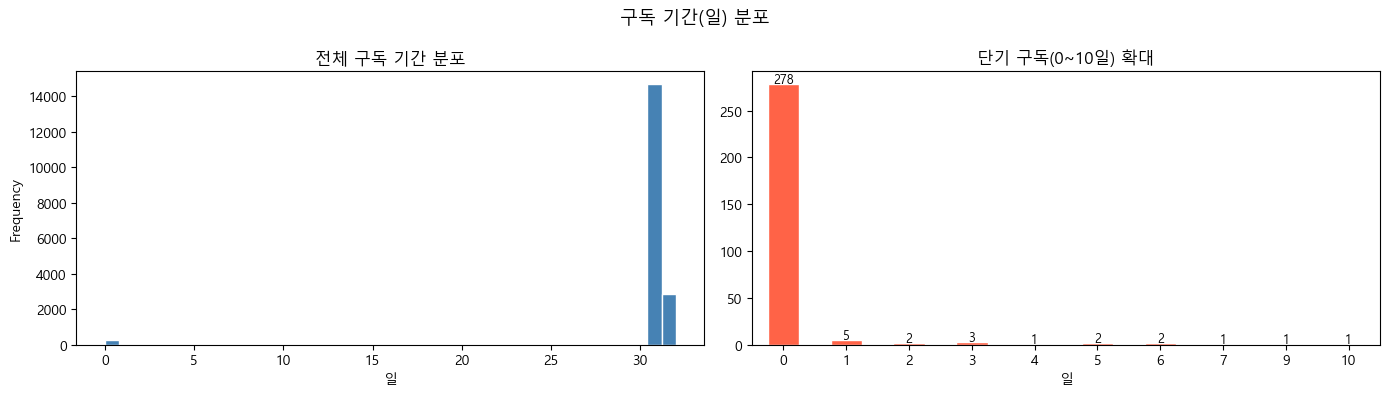

0일(당일 취소): 278건
1~7일 이내 취소: 16건
30일 이상 유지:  17,540건


In [83]:
# 구독 기간(일) 분포 — 며칠 만에 취소가 많은지 확인
membership_c['reg_date'] = pd.to_datetime(membership_c['reg_date'])
membership_c['end_date'] = pd.to_datetime(membership_c['end_date'])
membership_c['sub_days'] = (membership_c['end_date'] - membership_c['reg_date']).dt.days

print('[구독 기간 분포 (상위 15개)]')
print(membership_c['sub_days'].value_counts().sort_index().head(15))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('구독 기간(일) 분포', fontsize=13)

# 전체 분포
membership_c['sub_days'].plot(kind='hist', bins=40, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('전체 구독 기간 분포')
axes[0].set_xlabel('일')

# 단기(0~10일) 확대
membership_c[membership_c['sub_days'] <= 10]['sub_days'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='tomato', edgecolor='white')
axes[1].set_title('단기 구독(0~10일) 확대')
axes[1].set_xlabel('일')
axes[1].tick_params(axis='x', rotation=0)
for p in axes[1].patches:
    axes[1].text(p.get_x() + p.get_width()/2, p.get_height() + 1,
                 str(int(p.get_height())), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f'0일(당일 취소): {(membership_c["sub_days"]==0).sum():,}건')
print(f'1~7일 이내 취소: {membership_c["sub_days"].between(1,7).sum():,}건')
print(f'30일 이상 유지:  {(membership_c["sub_days"]>=30).sum():,}건')


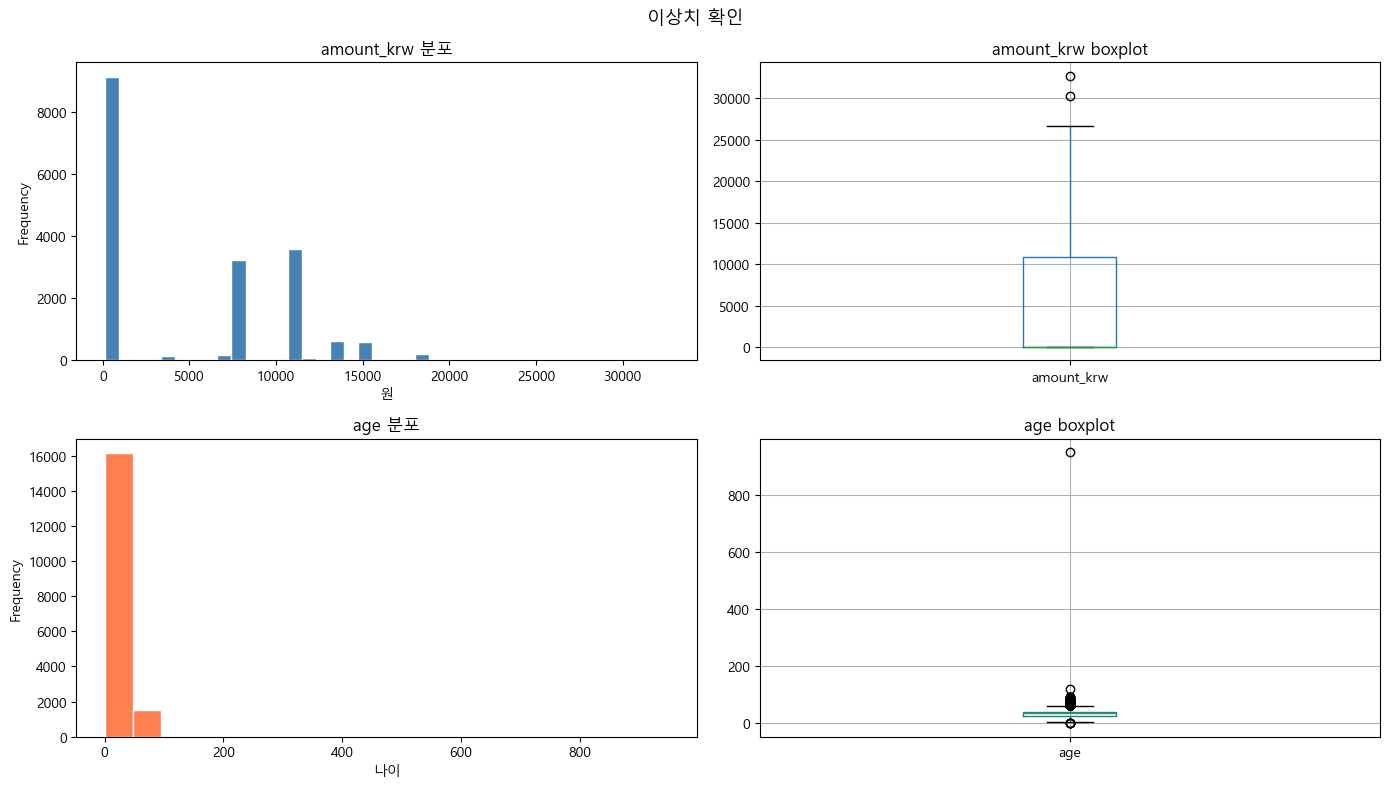

[amount_krw 기초 통계]
count    17845.0
mean      5055.1
std       5429.4
min        100.0
25%        100.0
50%        100.0
75%      10900.0
max      32659.0
Name: amount_krw, dtype: float64

[age 기초 통계]
count    17693.0
mean        33.9
std         12.7
min          0.0
25%         25.0
50%         35.0
75%         40.0
max        950.0
Name: age, dtype: float64

[amount_krw] IQR 기준 이상치: 2건 (하한 -16100 / 상한 27100)
[age] IQR 기준 이상치: 242건 (하한 2 / 상한 62)


In [84]:
# amount_krw, age 이상치 확인
membership_c['is_usd'] = membership_c['amount'] % 1 != 0
membership_c['amount_krw'] = membership_c.apply(
    lambda x: round(x['amount'] * 1100) if x['is_usd'] else x['amount'], axis=1)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('이상치 확인', fontsize=13)

# amount_krw 분포
membership_c['amount_krw'].plot(kind='hist', bins=40, ax=axes[0,0], color='steelblue', edgecolor='white')
axes[0,0].set_title('amount_krw 분포')
axes[0,0].set_xlabel('원')

# amount_krw boxplot
membership_c.boxplot(column='amount_krw', ax=axes[0,1])
axes[0,1].set_title('amount_krw boxplot')

# age 분포
membership_c['age'].dropna().plot(kind='hist', bins=20, ax=axes[1,0], color='coral', edgecolor='white')
axes[1,0].set_title('age 분포')
axes[1,0].set_xlabel('나이')

# age boxplot
membership_c[['age']].dropna().boxplot(ax=axes[1,1])
axes[1,1].set_title('age boxplot')

plt.tight_layout()
plt.show()

print('[amount_krw 기초 통계]')
print(membership_c['amount_krw'].describe().round(1))
print()
print('[age 기초 통계]')
print(membership_c['age'].describe().round(1))
print()
# IQR 기준 이상치 개수
for col in ['amount_krw', 'age']:
    q1 = membership_c[col].quantile(0.25)
    q3 = membership_c[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = membership_c[(membership_c[col] < lower) | (membership_c[col] > upper)]
    print(f'[{col}] IQR 기준 이상치: {len(outliers):,}건 (하한 {lower:.0f} / 상한 {upper:.0f})')

--- 연령대별 데이터 분포 ---
age_group
0-9        6
10s      324
20s     5479
30s     4434
40s     5906
50s     1080
60s      357
70s       76
80s       25
90s        4
100+       2
Name: count, dtype: int64

80세 이상 전체 데이터 개수: 31개

--- 80세 이상 데이터 상세 내역 (상위 10개) ---
                                                 user_no    age product_cd  \
14589  c2965f476564ba6e82061bfff3437d238a665a562be040...  950.0    pk_2025   
12851  c5e66373e9d542412c3e83f3c664bf6d87edec5e957f07...  120.0    pk_1489   
12282  3cad0b78798a6d542be7c6ee1da68f1e9f097435459d55...   90.0    pk_1487   
2278   97732a4c39a396857b5bf6e681b39de8bc5b06334c728a...   90.0    pk_2025   
16823  e308baf21c4aaf49299d42f16914e50f48d64f3837f03d...   90.0    pk_1488   
9417   ac5b9bf973305e65778b647a66874cf198acdaf1a6d28c...   90.0    pk_1489   
10990  6661a514b72bfaf7d7fccb1790063d4faf872b1a95609f...   85.0    pk_2026   
7886   ff0888450bd7f135e97ae6b22fad85abe7955ca365bc63...   85.0    pk_1487   
1428   455b9fa8ffe849b0082639edc82650e5bb

C:\Users\82109\AppData\Local\Temp\ipykernel_10968\3215098348.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=membership_c, x='age_group', palette='viridis')


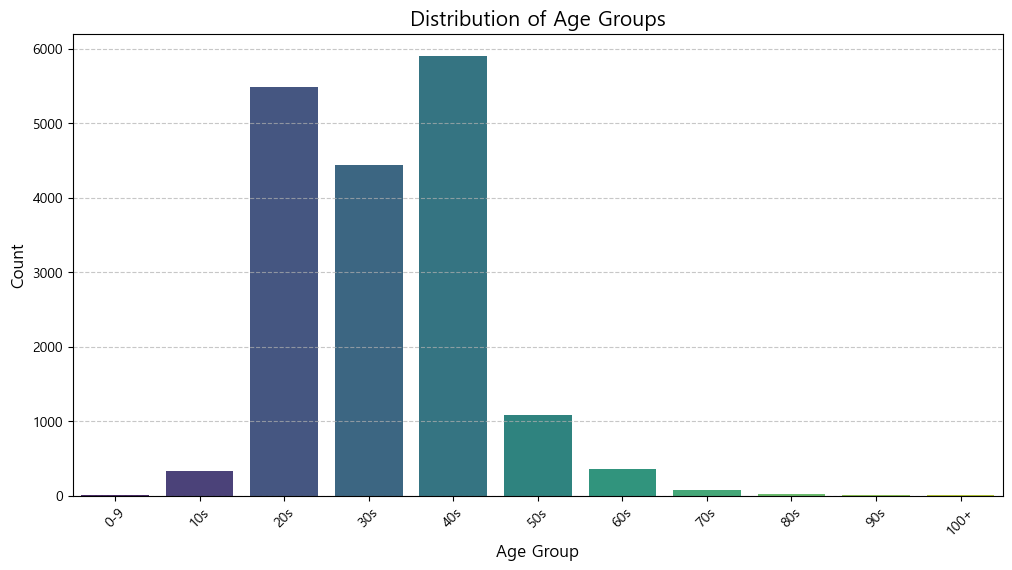

In [85]:
# 연령대 구간 설정
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 1000]
labels = ['0-9', '10s', '20s', '30s', '40s', '50s', '60s', '70s', '80s', '90s', '100+']

membership_c['age_group'] = pd.cut(membership_c['age'], bins=bins, labels=labels, right=False)

# 구간별 데이터 개수 확인
age_counts = membership_c['age_group'].value_counts().sort_index()

# 실제로 이상치가 의심되는 데이터(예: 80세 이상)만 따로 추출해서 확인
elderly_data = membership_c[membership_c['age'] >= 80][['user_no', 'age', 'product_cd', 'reg_date']].sort_values(by='age', ascending=False)

print("--- 연령대별 데이터 분포 ---")
print(age_counts)
print(f"\n80세 이상 전체 데이터 개수: {len(elderly_data)}개")
plt.figure(figsize=(12, 6))
sns.countplot(data=membership_c, x='age_group', palette='viridis')

plt.title('Distribution of Age Groups', fontsize=15)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
print("\n--- 80세 이상 데이터 상세 내역 (상위 10개) ---")
print(elderly_data.head(10))

In [86]:
# age 이상치 처리
before = len(membership_c)

# 1) age < 10 또는 age >= 100 제거
membership_c = membership_c[membership_c['age'].isna() | 
                            membership_c['age'].between(10, 99)].reset_index(drop=True)

after = len(membership_c)
print(f'age 이상치 제거: {before:,} → {after:,} ({before-after}건 제거)')
print()

# 2) 연령대 컬럼 생성 (70세 이상 → '70+')
def age_group(age):
    if pd.isna(age): return 'unknown'
    elif age < 20:   return '10s'
    elif age < 30:   return '20s'
    elif age < 40:   return '30s'
    elif age < 50:   return '40s'
    elif age < 60:   return '50s'
    elif age < 70:   return '60s'
    else:            return '70+'

membership_c['age_group'] = membership_c['age'].apply(age_group)

print('[처리 후 연령대 분포]')
print(membership_c['age_group'].value_counts().sort_index())


age 이상치 제거: 17,845 → 17,837 (8건 제거)

[처리 후 연령대 분포]
age_group
10s         324
20s        5479
30s        4434
40s        5906
50s        1080
60s         357
70+         105
unknown     152
Name: count, dtype: int64


In [87]:
# amount 75% 초과 상품 목록
membership_c['is_usd'] = membership_c['amount'] % 1 != 0
membership_c['amount_krw'] = membership_c.apply(
    lambda x: round(x['amount'] * 1100) if x['is_usd'] else x['amount'], axis=1)

q75 = membership_c['amount_krw'].quantile(0.75)
print(f'Q75 기준값: {q75:,.0f}원')
print()

over_q75 = membership_c[membership_c['amount_krw'] > q75].copy()

def format_price(row):
    if row['is_usd']:
        return f"{row['amount_krw']:,.0f}원 ({row['amount']}$)"
    else:
        return f"{row['amount_krw']:,.0f}원"

over_q75['가격표시'] = over_q75.apply(format_price, axis=1)

result = (over_q75.groupby(['product_cd','가격표시','amount_krw'])
          .size().reset_index(name='건수')
          .sort_values('amount_krw'))

print(f'[75% 초과 (>{q75:,.0f}원) 상품 목록]')
print(result[['product_cd','가격표시','건수']].to_string(index=False))
print(f'총 {len(over_q75):,}건 / 전체 {len(membership_c):,}건 ({len(over_q75)/len(membership_c)*100:.1f}%)')

Q75 기준값: 10,900원

[75% 초과 (>10,900원) 상품 목록]
product_cd             가격표시   건수
   pk_1508  10,989원 (9.99$) 2068
   pk_1350          11,550원    1
   pk_1898          11,800원    2
   pk_1136 12,089원 (10.99$)   27
    pk_141 12,089원 (10.99$)    5
    pk_138 12,089원 (10.99$)    1
    pk_844 12,089원 (10.99$)   42
   pk_1494          13,750원   24
   pk_2028          13,750원    6
   pk_1489          13,900원  504
   pk_2027          13,900원   76
   pk_1145 14,509원 (13.19$)    1
    pk_140 14,509원 (13.19$)    1
    pk_846 14,509원 (13.19$)    4
   pk_1506 14,839원 (13.49$)  582
    pk_845 15,719원 (14.29$)    9
    pk_142 15,719원 (14.29$)    2
   pk_1139 15,719원 (14.29$)    7
   pk_1079          16,400원    1
   pk_1509 18,139원 (16.49$)    7
   pk_1142 18,139원 (16.49$)    3
    pk_847 18,139원 (16.49$)    2
   pk_1507 18,139원 (16.49$)  200
    pk_848 19,349원 (17.59$)    1
   pk_1510 22,539원 (20.49$)    1
   pk_1143 24,189원 (21.99$)    1
    pk_849 24,189원 (21.99$)    1
   pk_1157 26,609원 (24.19$)    1

In [88]:
# 20,000원 이상 이상치 상세 확인
over_20k = membership_c[membership_c['amount_krw'] >= 20000]
print(f'20,000원 이상: {len(over_20k)}건')
print()
print(over_20k[['product_cd','amount','amount_krw','payment_device',
                 'gender','age','reg_date','end_date','repurchase',
                 'is_churn_prevented','promotion_yn','is_user_verified']].to_string())

20,000원 이상: 6건

      product_cd  amount  amount_krw payment_device gender   age   reg_date   end_date repurchase is_churn_prevented promotion_yn is_user_verified
2443      pk_849   21.99     24189.0            ios      F  25.0 2021-03-13 2021-04-14          O                  N            N                Y
6447     pk_1158   29.69     32659.0            ios      M  40.0 2021-03-09 2021-04-10        NaN                  N            N                Y
7497     pk_1157   24.19     26609.0            ios      N  40.0 2021-03-08 2021-04-09        NaN                  N            N                N
10275    pk_1160   27.49     30239.0            ios      N  40.0 2021-03-06 2021-04-07          O                  N            N                N
10501    pk_1143   21.99     24189.0            ios      N  40.0 2021-03-06 2021-04-07        NaN                  N            N                N
13446    pk_1510   20.49     22539.0            ios      N  40.0 2021-03-04 2021-04-05          O     

In [89]:
# amount_krw 상한 대체 (20,000원 이상 → 19,349원으로 대체)
cap = 19349
before = (membership_c['amount_krw'] >= 20000).sum()

membership_c['amount_krw'] = membership_c['amount_krw'].clip(upper=cap)

print(f'상한 대체 완료: {before}건 → 19,349원으로 대체')
print(f'amount_krw 최대값: {membership_c["amount_krw"].max():,.0f}원')
print()
print('[amount_krw 기초 통계]')
print(membership_c['amount_krw'].describe().round(0))

# CSV 저장
membership_c.to_csv('Membership_전처리.csv', index=False, encoding='utf-8-sig')
print('Membership_전처리.csv 저장 완료')

상한 대체 완료: 6건 → 19,349원으로 대체
amount_krw 최대값: 19,349원

[amount_krw 기초 통계]
count    17837.0
mean      5050.0
std       5421.0
min        100.0
25%        100.0
50%        100.0
75%      10900.0
max      19349.0
Name: amount_krw, dtype: float64


Membership_전처리.csv 저장 완료


### 1-4. 전처리 전후 비교

In [90]:
# 데이터 크기 and 결측치 변화
membership_orig = pd.read_csv('Membership.csv')
membership_post = pd.read_csv('Membership_전처리.csv')

print('[데이터 크기]')
print(f'  원본   : {membership_orig.shape[0]:,}행 x {membership_orig.shape[1]}열')
print(f'  전처리 : {membership_post.shape[0]:,}행 x {membership_post.shape[1]}열')
print(f'  제거된 행: {membership_orig.shape[0] - membership_post.shape[0]:,}건')
print()
print('[결측치 현황 원본→전처리]')
cols_check = ['gender','age','is_user_verified','promotion_yn','is_churn_prevented','concurrent_streams']
for col in cols_check:
    if col in membership_orig.columns and col in membership_post.columns:
        b = membership_orig[col].isna().sum()
        a = membership_post[col].isna().sum()
        print(f'  {col:<22}: {b:>5}건 → {a:>5}건')

# concurrent_streams NaN 변화 상세
orig_nan3 = (membership_orig['concurrent_streams'] == 3).sum()
print()
print('[concurrent_streams NaN 변화 상세]')
print(f'  원본 NaN             : {membership_orig["concurrent_streams"].isna().sum()}건')
print(f'  원본 ==3 (결측처리됨): {orig_nan3}건')
print(f'  중복/이상치 제거로 NaN 행 함께 제거됨 → 순증가분 상쇄')
print(f'  전처리 최종 NaN      : {membership_post["concurrent_streams"].isna().sum()}건')
print(f'  * concurrent==3 을 NaN으로 전환했지만,')
print(f'    중복제거(338건)+age이상치제거(8건) 과정에서 NaN 보유 행 10건이 함께 제거됨')
print(f'    결과: 원본 NaN {membership_orig["concurrent_streams"].isna().sum()}건 → 전처리 {membership_post["concurrent_streams"].isna().sum()}건 (감소처럼 보이지만 정상)')


[데이터 크기]
  원본   : 18,183행 x 15열
  전처리 : 17,837행 x 19열
  제거된 행: 346건

[결측치 현황 원본→전처리]
  gender                :   164건 →     0건
  age                   :   164건 →   152건
  is_user_verified      :   600건 →     0건
  promotion_yn          :  8980건 →     0건
  is_churn_prevented    : 14926건 →     0건
  concurrent_streams    :    70건 →    67건

[concurrent_streams NaN 변화 상세]
  원본 NaN             : 70건
  원본 ==3 (결측처리됨): 7건
  중복/이상치 제거로 NaN 행 함께 제거됨 → 순증가분 상쇄
  전처리 최종 NaN      : 67건
  * concurrent==3 을 NaN으로 전환했지만,
    중복제거(338건)+age이상치제거(8건) 과정에서 NaN 보유 행 10건이 함께 제거됨
    결과: 원본 NaN 70건 → 전처리 67건 (감소처럼 보이지만 정상)


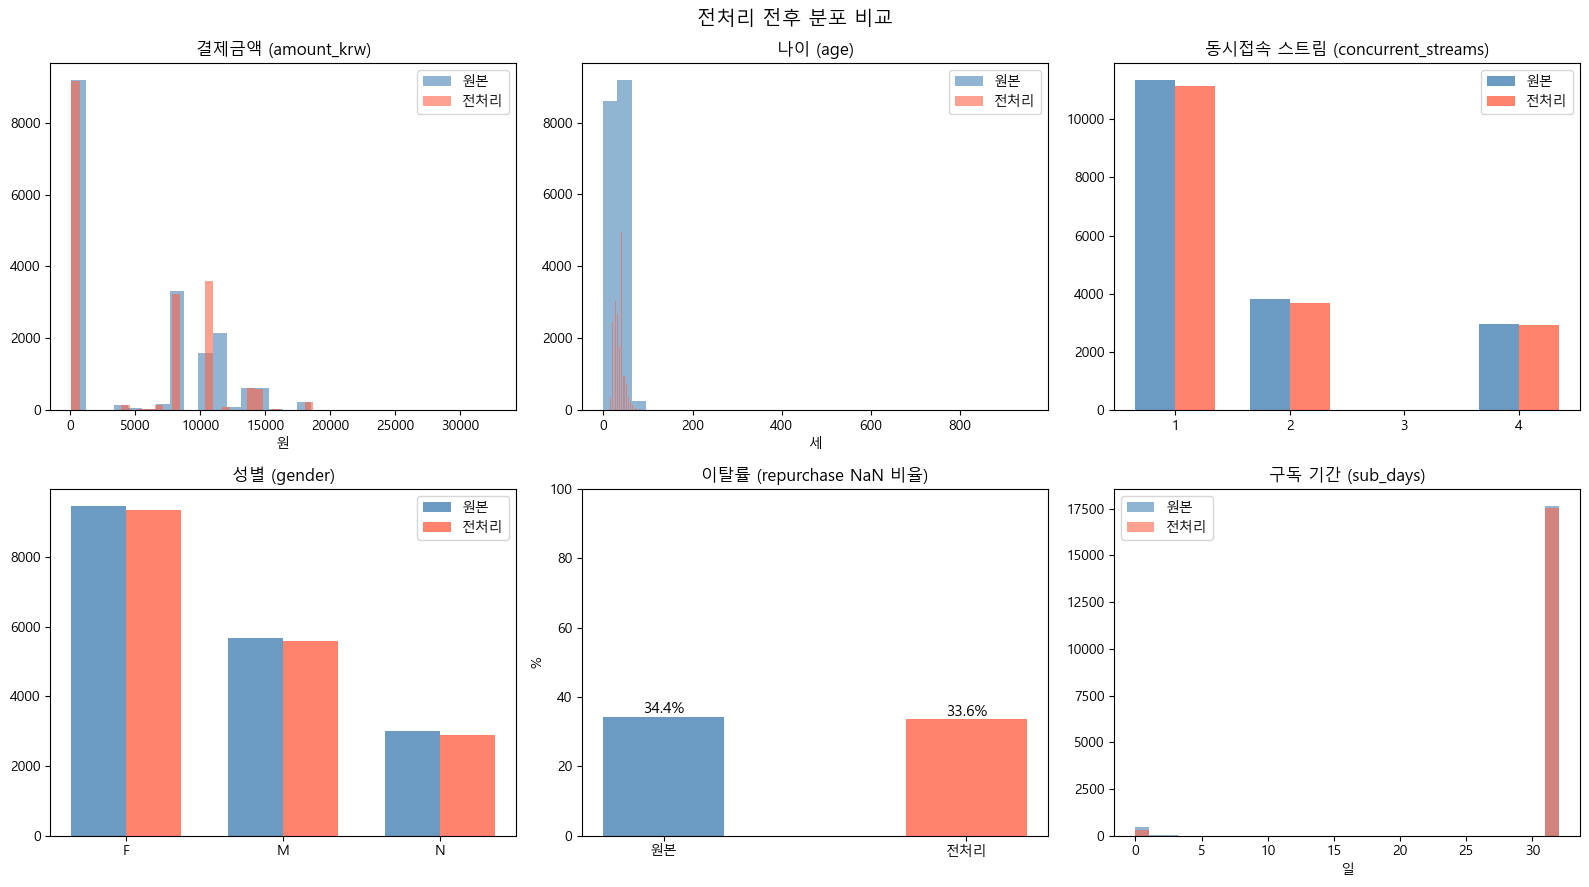

In [91]:
# 주요 컬럼 분포 비교 (원본 vs 전처리)
membership_orig = pd.read_csv('Membership.csv')
membership_post = pd.read_csv('Membership_전처리.csv')
membership_orig['is_usd'] = membership_orig['amount'] % 1 != 0
membership_orig['amount_krw'] = membership_orig.apply(lambda x: round(x['amount']*1100) if x['is_usd'] else x['amount'], axis=1)
membership_orig['reg_date'] = pd.to_datetime(membership_orig['reg_date'])
membership_orig['end_date'] = pd.to_datetime(membership_orig['end_date'])
membership_orig['sub_days'] = (membership_orig['end_date'] - membership_orig['reg_date']).dt.days

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('전처리 전후 분포 비교', fontsize=14)
w = 0.35

# 1) amount_krw
axes[0,0].hist(membership_orig['amount_krw'].dropna(), bins=30, color='steelblue', alpha=0.6, label='원본')
axes[0,0].hist(membership_post['amount_krw'].dropna(), bins=30, color='tomato', alpha=0.6, label='전처리')
axes[0,0].set_title('결제금액 (amount_krw)')
axes[0,0].set_xlabel('원')
axes[0,0].legend()

# 2) age
axes[0,1].hist(membership_orig['age'].dropna(), bins=30, color='steelblue', alpha=0.6, label='원본')
axes[0,1].hist(membership_post['age'].dropna(), bins=30, color='tomato', alpha=0.6, label='전처리')
axes[0,1].set_title('나이 (age)')
axes[0,1].set_xlabel('세')
axes[0,1].legend()

# 3) concurrent_streams
orig_cs = membership_orig['concurrent_streams'].value_counts().sort_index()
post_cs = membership_post['concurrent_streams'].value_counts().sort_index()
x_vals = sorted(set(list(orig_cs.index) + list(post_cs.index)))
axes[0,2].bar([i-w/2 for i in range(len(x_vals))], [orig_cs.get(v,0) for v in x_vals], width=w, color='steelblue', alpha=0.8, label='원본')
axes[0,2].bar([i+w/2 for i in range(len(x_vals))], [post_cs.get(v,0) for v in x_vals], width=w, color='tomato', alpha=0.8, label='전처리')
axes[0,2].set_xticks(range(len(x_vals)))
axes[0,2].set_xticklabels([str(int(v)) for v in x_vals])
axes[0,2].set_title('동시접속 스트림 (concurrent_streams)')
axes[0,2].legend()

# 4) gender
orig_g = membership_orig['gender'].fillna('N').value_counts()
post_g = membership_post['gender'].value_counts()
g_labels = ['F','M','N']
axes[1,0].bar([i-w/2 for i in range(3)], [orig_g.get(l,0) for l in g_labels], width=w, color='steelblue', alpha=0.8, label='원본')
axes[1,0].bar([i+w/2 for i in range(3)], [post_g.get(l,0) for l in g_labels], width=w, color='tomato', alpha=0.8, label='전처리')
axes[1,0].set_xticks(range(3))
axes[1,0].set_xticklabels(g_labels)
axes[1,0].set_title('성별 (gender)')
axes[1,0].legend()

# 5) 이탈률
orig_churn = membership_orig['repurchase'].isna().mean() * 100
post_churn = membership_post['repurchase'].isna().mean() * 100
bars = axes[1,1].bar(['원본','전처리'], [orig_churn, post_churn], color=['steelblue','tomato'], alpha=0.8, width=0.4)
axes[1,1].set_title('이탈률 (repurchase NaN 비율)')
axes[1,1].set_ylabel('%')
axes[1,1].set_ylim(0, 100)
for bar, val in zip(bars, [orig_churn, post_churn]):
    axes[1,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{val:.1f}%', ha='center', fontsize=11)

# 6) sub_days
axes[1,2].hist(membership_orig['sub_days'].dropna(), bins=30, color='steelblue', alpha=0.6, label='원본')
axes[1,2].hist(membership_post['sub_days'].dropna(), bins=30, color='tomato', alpha=0.6, label='전처리')
axes[1,2].set_title('구독 기간 (sub_days)')
axes[1,2].set_xlabel('일')
axes[1,2].legend()

plt.tight_layout()
plt.show()


In [92]:
# 주요 통계 변화 요약
membership_orig = pd.read_csv('Membership.csv')
membership_post = pd.read_csv('Membership_전처리.csv')
membership_orig['is_usd'] = membership_orig['amount'] % 1 != 0
membership_orig['amount_krw'] = membership_orig.apply(lambda x: round(x['amount']*1100) if x['is_usd'] else x['amount'], axis=1)
membership_orig['reg_date'] = pd.to_datetime(membership_orig['reg_date'])
membership_orig['end_date'] = pd.to_datetime(membership_orig['end_date'])
membership_orig['sub_days'] = (membership_orig['end_date'] - membership_orig['reg_date']).dt.days

n_o, n_p = len(membership_orig), len(membership_post)
cr_o = membership_orig['repurchase'].isna().mean() * 100
cr_p = membership_post['repurchase'].isna().mean() * 100
am_o = membership_orig['amount_krw'].mean()
am_p = membership_post['amount_krw'].mean()
ag_o = membership_orig['age'].mean()
ag_p = membership_post['age'].mean()
sd_o = membership_orig['sub_days'].mean()
sd_p = membership_post['sub_days'].mean()
gn_o = membership_orig['gender'].isna().mean() * 100
gn_p = membership_post['gender'].isna().mean() * 100
cn_o = membership_orig['concurrent_streams'].isna().mean() * 100
cn_p = membership_post['concurrent_streams'].isna().mean() * 100

print('[주요 통계 변화 요약]')
hdr = f'{"항목":<25} {"원본":>12} {"전처리":>12} {"변화":>10}'
print(hdr)
print('-' * 62)
print(f'{"전체 행 수":<25} {n_o:>12,} {n_p:>12,} {n_p-n_o:>+10,}')
print(f'{"이탈률 (%)":<25} {cr_o:>11.1f}% {cr_p:>11.1f}% {cr_p-cr_o:>+9.1f}%')
print(f'{"amount_krw 평균":<25} {am_o:>11,.0f} {am_p:>11,.0f} {am_p-am_o:>+9,.0f}')
print(f'{"age 평균":<25} {ag_o:>11.1f} {ag_p:>11.1f} {ag_p-ag_o:>+9.1f}')
print(f'{"sub_days 평균":<25} {sd_o:>11.1f} {sd_p:>11.1f} {sd_p-sd_o:>+9.1f}')
print(f'{"gender NaN %":<25} {gn_o:>11.1f}% {gn_p:>11.1f}% {gn_p-gn_o:>+9.1f}%')
print(f'{"concurrent NaN %":<25} {cn_o:>11.1f}% {cn_p:>11.1f}% {cn_p-cn_o:>+9.1f}%')


[주요 통계 변화 요약]
항목                                  원본          전처리         변화
--------------------------------------------------------------
전체 행 수                          18,183       17,837       -346
이탈률 (%)                          34.4%        33.6%      -0.8%
amount_krw 평균                   5,136       5,050       -86
age 평균                           33.9        33.8      -0.1
sub_days 평균                      30.3        30.6      +0.3
gender NaN %                      0.9%         0.0%      -0.9%
concurrent NaN %                  0.4%         0.4%      -0.0%


---
## Step 2. 피처 엔지니어링

### 2-1. 타깃 변수 생성 (is_churn)

In [93]:
# 전처리 파일 로드
membership_c   = pd.read_csv('Membership_전처리.csv')
user_mapping_c = pd.read_csv('User_Mapping_전처리.csv')

# is_churn: repurchase NaN = 이탈(1), 값 있음 = 재구매(0)
membership_c['is_churn'] = membership_c['repurchase'].isna().astype(int)

print('[이탈 여부 분포]')
churn_cnt = membership_c['is_churn'].value_counts()
n = len(membership_c)
print(f'  재구매(0): {churn_cnt.get(0,0):,}명  ({churn_cnt.get(0,0)/n*100:.1f}%)')
print(f'  이탈  (1): {churn_cnt.get(1,0):,}명  ({churn_cnt.get(1,0)/n*100:.1f}%)')


[이탈 여부 분포]
  재구매(0): 11,840명  (66.4%)
  이탈  (1): 5,997명  (33.6%)


### 2-2. 시청 행동 피처

In [94]:
view_history = pd.read_csv('View_History.csv')

# 영화별 최대 DURATION = 영화 길이 프록시
movie_len = view_history.groupby('MOVIE_ID')['DURATION'].max().rename('movie_len')
vh = view_history.merge(movie_len, on='MOVIE_ID')

# (USER_ID, MOVIE_ID)별로 DURATION 합산 → 나눠서 본 경우 합치기
vh_movie = vh.groupby(['USER_ID', 'MOVIE_ID']).agg(
    total_movie_duration = ('DURATION', 'sum'),
    movie_len            = ('movie_len', 'first'),
).reset_index()

# watch_ratio: clip 없음 → 재시청 정보 보존 (1.5 = 1.5배 시청)
vh_movie['watch_ratio']  = vh_movie['total_movie_duration'] / vh_movie['movie_len']
# completion: clip(1.0) → "끝까지 봤는가" 여부
vh_movie['completion']   = vh_movie['watch_ratio'].clip(upper=1.0)
# rewatch 여부: ratio > 1.0이면 재시청
vh_movie['is_rewatch']   = (vh_movie['watch_ratio'] > 1.0).astype(int)

# USER_ID 기준 집계
view_feat = vh.groupby('USER_ID').agg(
    watch_count    = ('MOVIE_ID', 'count'),
    unique_movies  = ('MOVIE_ID', 'nunique'),
    active_days    = ('WATCH_DAY', 'nunique'),
    total_duration = ('DURATION', 'sum'),
    avg_duration   = ('DURATION', 'mean'),
).reset_index()

# 영화 단위 집계 피처 추가
movie_agg = vh_movie.groupby('USER_ID').agg(
    avg_completion    = ('completion',  'mean'),   # 평균 완주율 (0~1)
    avg_rewatch_ratio = ('watch_ratio', 'mean'),   # 평균 시청 배율 (재시청 포함, >1 가능)
    rewatch_count     = ('is_rewatch',  'sum'),    # 재시청한 영화 수
).reset_index()

view_feat = view_feat.merge(movie_agg, on='USER_ID', how='left')

print('[시청 행동 피처 기초 통계]')
print(view_feat.describe().round(2))
print(f'집계된 USER_ID 수: {len(view_feat):,}')
print()
print('[재시청 분포]')
print(f'  재시청 영화 있는 유저: {(view_feat["rewatch_count"] > 0).sum():,}명')
print(f'  평균 재시청 영화 수: {view_feat["rewatch_count"].mean():.2f}편')
print(f'  avg_rewatch_ratio 최대: {view_feat["avg_rewatch_ratio"].max():.2f} (clip 없음)')


[시청 행동 피처 기초 통계]
        USER_ID  watch_count  unique_movies  active_days  total_duration  \
count  14892.00     14892.00       14892.00     14892.00        14892.00   
mean    9930.40         7.13           5.10         3.90          317.13   
std     5749.72         5.97           4.26         2.56          327.53   
min        0.00         1.00           1.00         1.00            1.00   
25%     4965.75         3.00           2.00         2.00           98.00   
50%     9902.50         6.00           4.00         3.00          225.00   
75%    14949.25        10.00           7.00         5.00          436.00   
max    19875.00        75.00          67.00        21.00         4419.00   

       avg_duration  avg_completion  avg_rewatch_ratio  rewatch_count  
count      14892.00        14892.00           14892.00       14892.00  
mean          44.94            0.39               0.43           0.27  
std           30.56            0.25               0.34           0.63  
min       

### 2-3. 가입 직후 행동 (cold_start)

In [95]:
# WATCH_DAY: YYYYMMDD 정수 to datetime
vh_cs = view_history.copy()
vh_cs['watch_date'] = pd.to_datetime(vh_cs['WATCH_DAY'].astype(str), format='%Y%m%d')

# USER_ID별 첫 번째 시청일
first_watch = vh_cs.groupby('USER_ID')['watch_date'].min().rename('first_watch_date')

# Membership에 USER_ID 붙이기 (user_no to uid to USER_ID)
ms_uid = membership_c.merge(user_mapping_c, left_on='user_no', right_on='uid', how='left')
ms_uid['reg_date'] = pd.to_datetime(ms_uid['reg_date'])
ms_uid = ms_uid.merge(first_watch, on='USER_ID', how='left')

# cold_start: 가입 후 7일 이내 첫 시청 = 1
ms_uid['days_to_first_watch'] = (ms_uid['first_watch_date'] - ms_uid['reg_date']).dt.days
ms_uid['cold_start'] = (ms_uid['days_to_first_watch'] <= 7).astype(int)
ms_uid['cold_start'] = ms_uid['cold_start'].fillna(0).astype(int)

cold_feat = ms_uid[['USER_ID', 'days_to_first_watch', 'cold_start']].copy()

print('[cold_start 분포]')
cs_cnt = ms_uid['cold_start'].value_counts()
n = len(ms_uid)
print(f'  7일 내 첫 시청(1): {cs_cnt.get(1,0):,}명  ({cs_cnt.get(1,0)/n*100:.1f}%)')
print(f'  7일 초과/미시청(0): {cs_cnt.get(0,0):,}명  ({cs_cnt.get(0,0)/n*100:.1f}%)')
mean_days = ms_uid['days_to_first_watch'].mean()
print(f'첫 시청까지 평균 {mean_days:.1f}일')


[cold_start 분포]
  7일 내 첫 시청(1): 10,678명  (59.7%)
  7일 초과/미시청(0): 7,202명  (40.3%)
첫 시청까지 평균 5.4일


### 2-3-1. 주차별 시청 시간 & 리텐션 피처


In [96]:
# 가입일 기준 W1(1~7일) / W2(8~14일) / W3(15~21일) 시청 시간 및 리텐션
uid_reg = membership_c.merge(
    user_mapping_c[['uid', 'USER_ID']], left_on='user_no', right_on='uid', how='left')
uid_reg = uid_reg[['user_no', 'USER_ID', 'reg_date']].dropna(subset=['USER_ID']).copy()
uid_reg['reg_date'] = pd.to_datetime(uid_reg['reg_date'])
uid_reg['USER_ID'] = uid_reg['USER_ID'].astype(int)

vh_w = view_history.copy()
vh_w['watch_date'] = pd.to_datetime(vh_w['WATCH_DAY'].astype(str), format='%Y%m%d')
vh_w = vh_w.merge(uid_reg[['USER_ID', 'reg_date']], on='USER_ID', how='left')
vh_w = vh_w.dropna(subset=['reg_date'])
vh_w['days_since_reg'] = (vh_w['watch_date'] - vh_w['reg_date']).dt.days

vh_w['week'] = pd.cut(
    vh_w['days_since_reg'],
    bins=[-1, 7, 14, 21, 9999],
    labels=['w1', 'w2', 'w3', 'w4+']
)

week_dur = (
    vh_w.groupby(['USER_ID', 'week'])['DURATION']
    .sum()
    .unstack(fill_value=0)
    .reindex(columns=['w1', 'w2', 'w3', 'w4+'], fill_value=0)
)
week_dur.columns = ['dur_w1', 'dur_w2', 'dur_w3', 'dur_w4plus']
week_dur = week_dur.reset_index()

week_feat_base = uid_reg[['user_no', 'USER_ID']].merge(week_dur, on='USER_ID', how='left')
for col in ['dur_w1', 'dur_w2', 'dur_w3']:
    week_feat_base[col] = week_feat_base[col].fillna(0)
week_feat_base['retention_w2'] = (week_feat_base['dur_w2'] > 0).astype(int)
week_feat_base['retention_w3'] = (week_feat_base['dur_w3'] > 0).astype(int)

print(f'주차별 피처: {week_feat_base.shape}')
print(week_feat_base[['dur_w1','dur_w2','dur_w3','retention_w2','retention_w3']].describe().round(1))


주차별 피처: (17880, 8)
        dur_w1   dur_w2   dur_w3  retention_w2  retention_w3
count  17880.0  17880.0  17880.0       17880.0       17880.0
mean      98.6     83.1     82.2           0.6           0.6
std      161.8    143.2    141.8           0.5           0.5
min        0.0      0.0      0.0           0.0           0.0
25%        0.0      0.0      0.0           0.0           0.0
50%       14.0      3.0      3.0           1.0           1.0
75%      138.0    120.0    119.0           1.0           1.0
max     3415.0   3219.0   2575.0           1.0           1.0


C:\Users\82109\AppData\Local\Temp\ipykernel_10968\4120050216.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  vh_w.groupby(['USER_ID', 'week'])['DURATION']


### 2-4. RFM 피처

In [97]:
# R (Recency)   = recency_days: 마지막 시청 경과 일수 (sub_days 변별력 없어 교체)
# F (Frequency) = watch_count
# M (Monetary)  = amount_krw

vh_r = view_history.copy()
vh_r['watch_date'] = pd.to_datetime(vh_r['WATCH_DAY'].astype(str), format='%Y%m%d')
ref_date = vh_r['watch_date'].max()
last_watch = vh_r.groupby('USER_ID')['watch_date'].max().rename('last_watch_date')

ms_uid_r = membership_c.merge(user_mapping_c, left_on='user_no', right_on='uid', how='left')
ms_uid_r = ms_uid_r.merge(last_watch, on='USER_ID', how='left')
ms_uid_r['last_watch_date'] = pd.to_datetime(ms_uid_r['last_watch_date'])
ms_uid_r['recency_days'] = (ref_date - ms_uid_r['last_watch_date']).dt.days

max_recency = ms_uid_r['recency_days'].max()
ms_uid_r['recency_days'] = ms_uid_r['recency_days'].fillna(max_recency + 1)

recency_feat = ms_uid_r[['user_no', 'recency_days']].drop_duplicates('user_no')
print(f'recency_feat: {recency_feat.shape}')
print(recency_feat['recency_days'].describe().round(1))


recency_feat: (17837, 2)
count    17837.0
mean        16.8
std         10.7
min          0.0
25%          9.0
50%         15.0
75%         23.0
max         36.0
Name: recency_days, dtype: float64


### 2-5. 최종 피처 테이블 병합 & 저장

### 2-5-0. 장르 빈도 피처 (integrated_user_data 기반)


In [98]:
# (USER_ID, MOVIE_ID) 중복 제거 후 장르별 등장 횟수 / 고유 영화 수 = 빈도 비율
import sqlite3

conn = sqlite3.connect('integrated_analysis_통합본.db')
raw_genre = pd.read_sql(
    'SELECT USER_ID, MOVIE_ID, GENRE FROM integrated_user_data WHERE GENRE IS NOT NULL',
    conn
)
conn.close()

TARGET_GENRES = [
    '드라마','액션','스릴러','코미디','로맨스',
    '다큐멘터리','공포','범죄','SF','판타지',
    '가족','애니메이션','역사','전쟁'
]
movies_g = raw_genre.drop_duplicates(subset=['USER_ID','MOVIE_ID']).copy()
movies_g['genre_list'] = movies_g['GENRE'].str.split(',')
exploded_g = movies_g.explode('genre_list')
exploded_g['genre_list'] = exploded_g['genre_list'].str.strip()
exploded_g = exploded_g[exploded_g['genre_list'].isin(TARGET_GENRES)]
genre_count = exploded_g.groupby(['USER_ID','genre_list']).size().unstack(fill_value=0)
genre_count.columns = ['genre_' + c for c in genre_count.columns]
total_movies_g = movies_g.groupby('USER_ID')['MOVIE_ID'].nunique()
genre_ratio = genre_count.div(total_movies_g, axis=0).fillna(0).reset_index()
genre_cols = [c for c in genre_ratio.columns if c.startswith('genre_')]
print(f'장르 피처 생성 완료: {genre_ratio.shape}')
print(genre_ratio.head(2))


장르 피처 생성 완료: (14824, 15)
   USER_ID  genre_SF  genre_가족  genre_공포  genre_다큐멘터리  genre_드라마  genre_로맨스  \
0        0       0.6       0.2       0.0          0.0        0.6        0.2   
1        1       0.0       0.0       0.0          0.0        1.0        0.0   

   genre_범죄  genre_스릴러  genre_애니메이션  genre_액션  genre_역사  genre_전쟁  genre_코미디  \
0       0.0        0.6          0.2       0.6       0.0       0.0        0.4   
1       0.0        0.0          0.0       0.0       0.0       0.0        0.0   

   genre_판타지  
0        0.4  
1        0.0  


In [100]:
# membership_c 기준으로 모든 피처 병합
# (RFM 셀에서 watch_count 이미 추가됐으면 중복 방지를 위해 drop)
ms_merge = membership_c.drop(columns=['watch_count','watch_per_day'], errors='ignore')

feature_df = ms_merge.merge(user_mapping_c, left_on='user_no', right_on='uid', how='left')
feature_df = feature_df.merge(view_feat, on='USER_ID', how='left')
feature_df = feature_df.merge(genre_ratio, on='USER_ID', how='left')
feature_df = feature_df.merge(
    cold_feat[['USER_ID','days_to_first_watch','cold_start']], on='USER_ID', how='left')

# 시청 기록 없는 유저 -> 0 처리
feature_df = feature_df.merge(recency_feat, on='user_no', how='left')
feature_df = feature_df.merge(
    week_feat_base[['user_no','dur_w1','dur_w2','dur_w3','retention_w2','retention_w3']],
    on='user_no', how='left')

view_cols = ['watch_count','unique_movies','active_days','total_duration','avg_duration',
             'avg_completion','avg_rewatch_ratio','rewatch_count']
feature_df[view_cols] = feature_df[view_cols].fillna(0)
for col in genre_cols:
    feature_df[col] = feature_df[col].fillna(0)
feature_df['cold_start'] = feature_df['cold_start'].fillna(0).astype(int)
feature_df['days_to_first_watch'] = feature_df['days_to_first_watch'].fillna(-1)
for col in ['dur_w1', 'dur_w2', 'dur_w3']:
    feature_df[col] = feature_df[col].fillna(0)
feature_df['retention_w2'] = (feature_df['dur_w2'] > 0).astype(int)
feature_df['retention_w3'] = (feature_df['dur_w3'] > 0).astype(int)
feature_df['watch_per_day'] = feature_df['watch_count'] / (feature_df['sub_days'].replace(0, 1))

print(f'최종 피처 테이블: {feature_df.shape}')
print()
print('[컬럼 목록]')
print(feature_df.columns.tolist())
print()
null_check = feature_df.isnull().sum()
null_check = null_check[null_check > 0]
if len(null_check) == 0:
    print('결측치 없음')
else:
    print('[결측치 확인]')
    print(null_check)

# 기존 ratio_* 컬럼 제거 (DB 기반 → 새 genre_* 로 교체)
old_ratio = [c for c in feature_df.columns if c.startswith("ratio_")]
feature_df = feature_df.drop(columns=old_ratio)

feature_df.to_csv('features.csv', index=False, encoding='utf-8-sig')
print('features.csv 저장 완료')


최종 피처 테이블: (17968, 53)

[컬럼 목록]
['user_no', 'product_cd', 'amount', 'billing_method', 'concurrent_streams', 'promotion_yn', 'is_churn_prevented', 'repurchase', 'payment_device', 'is_user_verified', 'gender', 'age', 'reg_date', 'reg_hour', 'end_date', 'sub_days', 'is_usd', 'amount_krw', 'age_group', 'is_churn', 'uid', 'USER_ID', 'watch_count', 'unique_movies', 'active_days', 'total_duration', 'avg_duration', 'avg_completion', 'avg_rewatch_ratio', 'rewatch_count', 'genre_SF', 'genre_가족', 'genre_공포', 'genre_다큐멘터리', 'genre_드라마', 'genre_로맨스', 'genre_범죄', 'genre_스릴러', 'genre_애니메이션', 'genre_액션', 'genre_역사', 'genre_전쟁', 'genre_코미디', 'genre_판타지', 'days_to_first_watch', 'cold_start', 'recency_days', 'dur_w1', 'dur_w2', 'dur_w3', 'retention_w2', 'retention_w3', 'watch_per_day']

[결측치 확인]
concurrent_streams      73
repurchase            6092
age                    155
dtype: int64
features.csv 저장 완료
